Here, we filter the expr anndata object according to the extracted signaling network. We also embed the activity matrix in PCA/UMAP space.

In [1]:
import os
import ast
import json
import time

from tqdm import tqdm
from tqdm import trange

import numpy as np
import pandas as pd

import scanpy as sc
# import umap

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import preprocess as pp
from scLEMBAS import latent_separation as ls

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/nobackup/


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 


[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK


[pyKeOps] Compiling nvrtc binder for python ... 


[KeOps] Warning : There were warnings or errors :
In file included from /nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/pykeops/common/keops_io/pykeops_nvrtc.cpp:8:
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/keops_nvrtc.cpp:17:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
n_cores = 80
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'

In [3]:
adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_filtered_counts.h5ad'))

<span style="color:red; font-weight:bold">Delete This:</span>


In [4]:
# rng = np.random.default_rng(seed=888)
# n_frac = 0.01
# idx = rng.choice(adata.n_obs, size=int(adata.n_obs *n_frac), replace=False)
# adata = adata[idx, :]

# Preprocessing:

In [5]:
sc.pp.normalize_total(adata, target_sum = 1e6)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=3000, batch_key=None, flavor = 'seurat')

# Embeddings

In [6]:
covariate_associations = ['cell_line', 'drug', 'plate', 'phase', 'S_score', 'G2M_score', 'pcnt_mito']

## PCA Space

For embedding expr activity in PC space:
- no centering, as expr activities are already Z-scored
- don't use HVGs, as expr activity feature space is already limited
- automated elbow selection from 1-50 PC components
- if using clustering, identify a resolution that best clusters with cell_line + drug, as those are the two sources of variance we are most interested in


In [7]:
file_prefix = os.path.join(data_path, 'processed', author + '_expr_activity_pca')

In [8]:
adata, r2_df = ls.pc_pipeline(
    adata = adata,
    pert_ids = adata.obs.drug.unique(), # don't subset
    cat_ids = adata.obs.cell_line.unique(), # don't subset
    n_components = None, # estimate out of 50
    pert_col = 'drug',
    cat_col = 'cell_line',
    get_hvgs = False, # expr activity doesn't use HVGs 
    run_umap = True,
    covariate_associations = covariate_associations, 
    file_prefix = file_prefix,
    verbose = False,
    n_cores = n_cores,
    seed = 888,
    embkwrgs = {
        'cluster_data': False, 
        'scale': False,
        'pc_projection_tol': 1e-2,# typically 5e-4, but projection values are larger
        'pcakwrgs': {
            'use_highly_variable': True, 
            'zero_center': True
        }    
    }
)


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:374: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


/home/hmbaghda/Projects/scLEMBAS/scLEMBAS/latent_separation.py:282: UserWarning: Cannot reproduce scanpy pca projection
  warnings.warn('Cannot reproduce scanpy pca projection')


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


cell_line


  0%|                                                                                                | 0/12 [00:00<?, ?it/s]

...

 75%|██████████████████████████████████████████████████████████████████                      | 9/12 [04:33<01:26, 28.83s/it]

 83%|████████████████████████████████████████████████████████████████████████▌              | 10/12 [05:02<00:57, 28.82s/it]

 92%|███████████████████████████████████████████████████████████████████████████████▊       | 11/12 [05:30<00:28, 28.65s/it]

100%|███████████████████████████████████████████████████████████████████████████████████████| 12/12 [06:06<00:00, 30.82s/it]

100%|███████████████████████████████████████████████████████████████████████████████████████| 12/12 [06:06<00:00, 30.56s/it]

Elbow selection:

The elbow was automatically identified at PC 12


''

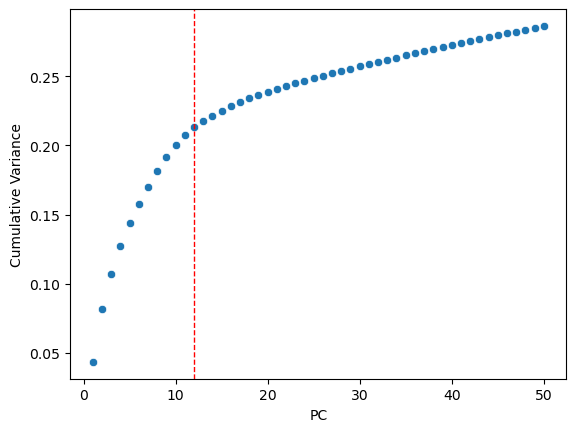

In [9]:
fig, ax = plt.subplots()
sns.scatterplot(
    y=np.cumsum(adata.uns['pca']['variance_ratio']),
    x=range(1, adata.uns['pca']['variance_ratio'].shape[0] + 1),
    ax=ax
)
ax.set_ylabel('Cumulative Variance')
ax.set_xlabel('PC')

n_pcs = adata.uns['pca']['pca_rank']
ax.axvline(x=n_pcs, color='red', linestyle='--', linewidth=1)

print('The elbow was automatically identified at PC {}'.format(n_pcs))
;

The two PC components that best univariately separate by drug are components 12 and 2 explaining 4.63% and 4.32% of variance, respectively
The two PC components that best univariately separate by cell_line are components 1 and 6 explaining 85.04% and 81.10% of variance, respectively


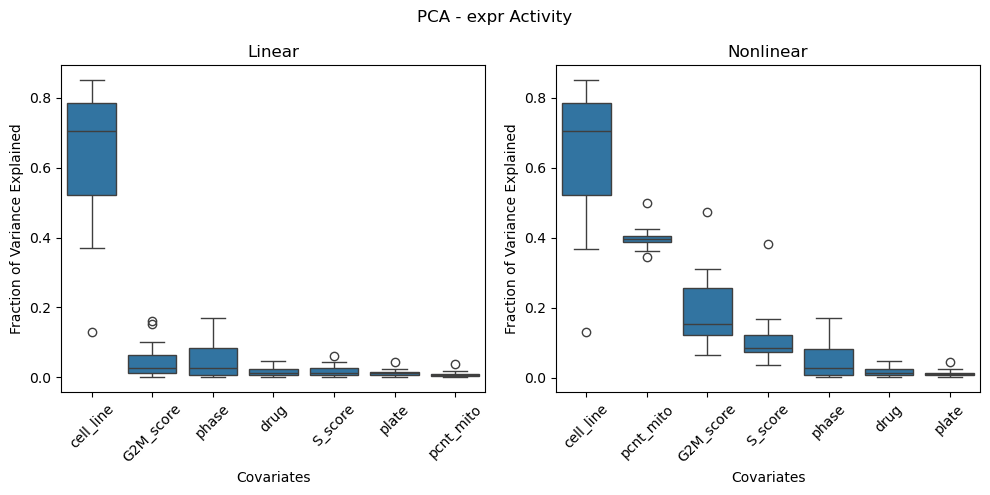

In [10]:
ls.visualize_latent_association(
    r2_df = r2_df, 
    fig_title = 'PCA - expr Activity', 
    file_name = file_prefix + '_associations.png'
)

top_components_drug = ls.get_top_components(r2_df, top_components_cov = 'drug')
top_components_cl = ls.get_top_components(r2_df, top_components_cov = 'cell_line')

In [11]:
pd.melt(
    r2_df.set_index(r2_df.columns[0]), 
    id_vars='model_type', 
    var_name='covariate'
).groupby(['model_type','covariate']).median().sort_values(by = ['model_type', 'value'])


value
model_type covariate          
linear     pcnt_mito  0.005721
           plate      0.011275
           S_score    0.012962
           drug       0.013205
           phase      0.026896
           G2M_score  0.027092
           cell_line  0.704329
nonlinear  plate      0.011275
           drug       0.013205
           phase      0.026896
           S_score    0.085617
           G2M_score  0.153798
           pcnt_mito  0.395587
           cell_line  0.704329

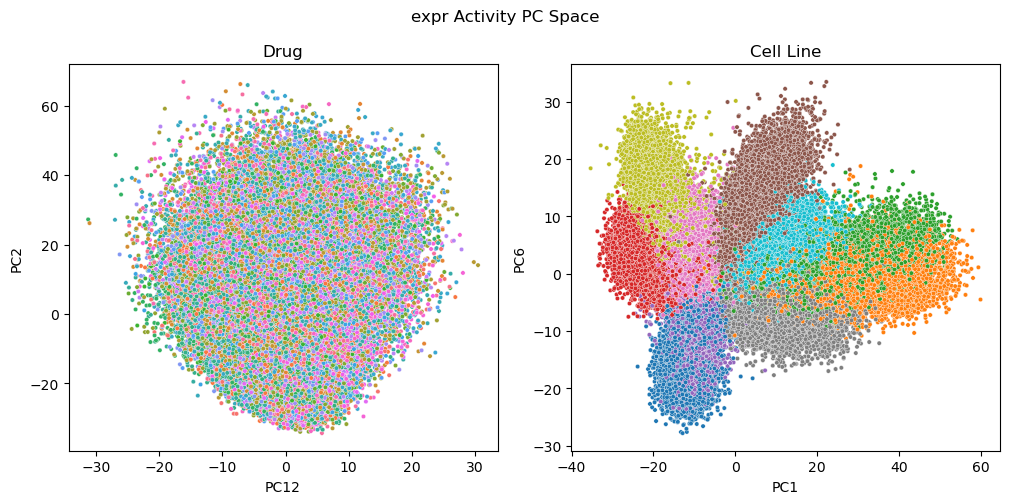

In [12]:
ls.visualize_latent_space(
    adata = adata, 
    latent_label = 'pca', 
    covariates = ['drug', 'cell_line'],
    panel_titles = ['Drug', 'Cell Line'],
    components = {'drug': top_components_drug, 
                  'cell_line': top_components_cl}, 
    n_frac = 0.2, 
    frac_col = None, 
    fig_title = 'expr Activity PC Space', 
    legend = False, 
    seed = 888, 
    file_name = file_prefix + '_space.png'
)

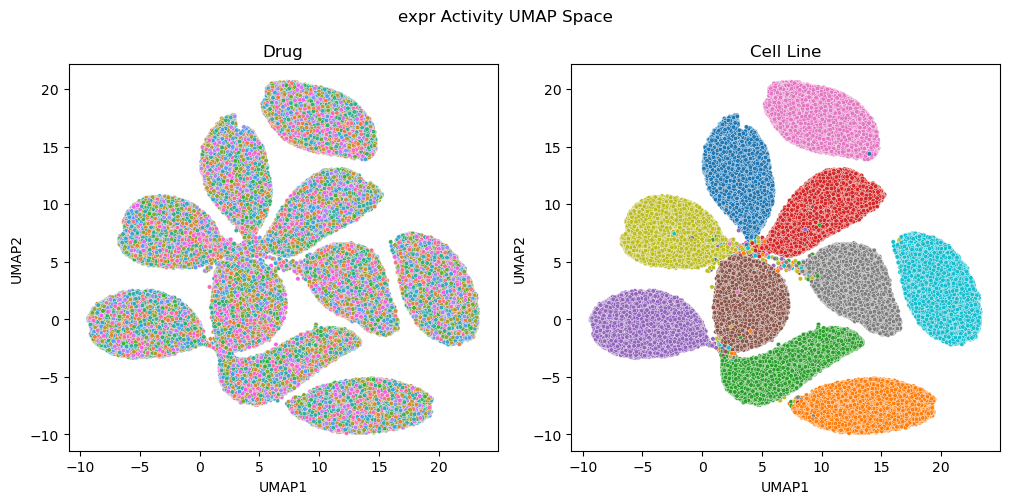

In [13]:
ls.visualize_latent_space(
    adata = adata, 
    latent_label = 'umap', 
    covariates = ['drug', 'cell_line'],
    panel_titles = ['Drug', 'Cell Line'],
    components = [1,2], 
    n_frac = 0.2, 
    frac_col = None, 
    fig_title = 'expr Activity UMAP Space', 
    legend = False, 
    seed = 888, 
    file_name = file_prefix + '_umap_space.png'
)

## PLS-DA 

For PLS-DA:
- again, we do not scale since the input is normalized
- we use our automated elbow analysis to identify the number of covariates
- umap is run categorically on drug
- we filter for HVGs for compute time (and bc this is more comparable with PCA)

In [14]:
file_prefix = os.path.join(data_path, 'processed', author + '_expr_activity_pls')
filter_hvgs_pls = True

In [15]:
if filter_hvgs_pls:
    adata = adata[:, adata.var['highly_variable']]

In [16]:
adata, r2_df = ls.pls_da_pipeline(
    adata = adata, 
    pert_ids = adata.obs.drug.unique(), # don't subset
    cat_ids = adata.obs.cell_line.unique(), # don't subset
    n_components = None, 
    pert_col = 'drug', 
    cat_col = 'cell_line', 
    separate_by = 'perturbation', 
    control_confounders = [], 
    covariate_associations = covariate_associations,
    scale = False, # expr activity already Z-scored
    run_umap = True, 
    file_prefix = file_prefix, 
    verbose = True,
    seed = seed, 
    n_cores = n_cores
)


Run elbow selection


  0%|                                                                                                | 0/25 [00:00<?, ?it/s]

  4%|███▍                                                                                 | 1/25 [09:47<3:55:00, 587.52s/it]

  8%|██████▊                                                                              | 2/25 [18:51<3:35:26, 562.04s/it]

 12%|██████████▏                                                                          | 3/25 [27:30<3:18:46, 542.13s/it]

...

 91%|███████████████████████████████████████████████████████████████████████████████        | 10/11 [05:30<00:32, 32.26s/it]

100%|███████████████████████████████████████████████████████████████████████████████████████| 11/11 [06:00<00:00, 31.43s/it]

100%|███████████████████████████████████████████████████████████████████████████████████████| 11/11 [06:00<00:00, 32.78s/it]


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Get UMAP


In [17]:
adata.uns['pls']['model_fit']

{'n_components': 11,
 'accuracy': 0.1332035663240999,
 'explained_y': 0.029349717786612106}

''

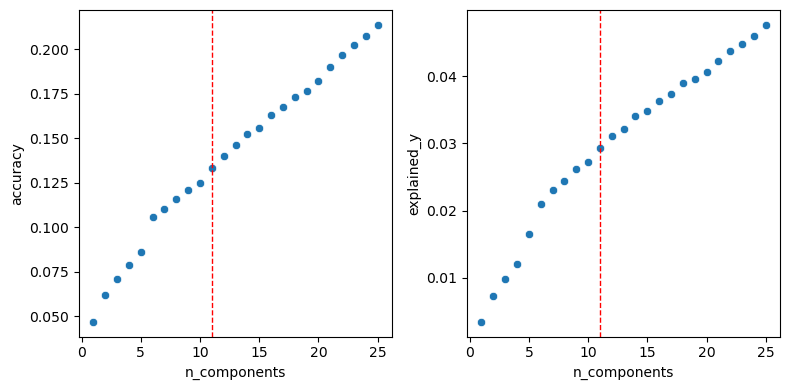

In [18]:
elbow_df = adata.uns['pls']['elbow_analysis']

n_components = adata.uns['pls']['model_fit']['n_components']
fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))
for (i, metric) in enumerate(['accuracy', 'explained_y']):
    sns.scatterplot(data = elbow_df, x = 'n_components', y = metric, ax = ax[i])
    ax[i].axvline(x=n_components, color='red', linestyle='--', linewidth=1)
   
    
fig.tight_layout()
;

The two PLS components that best univariately separate by drug are components 5 and 6 explaining 15.31% and 14.80% of variance, respectively
The two PLS components that best univariately separate by cell_line are components 8 and 10 explaining 63.76% and 61.39% of variance, respectively


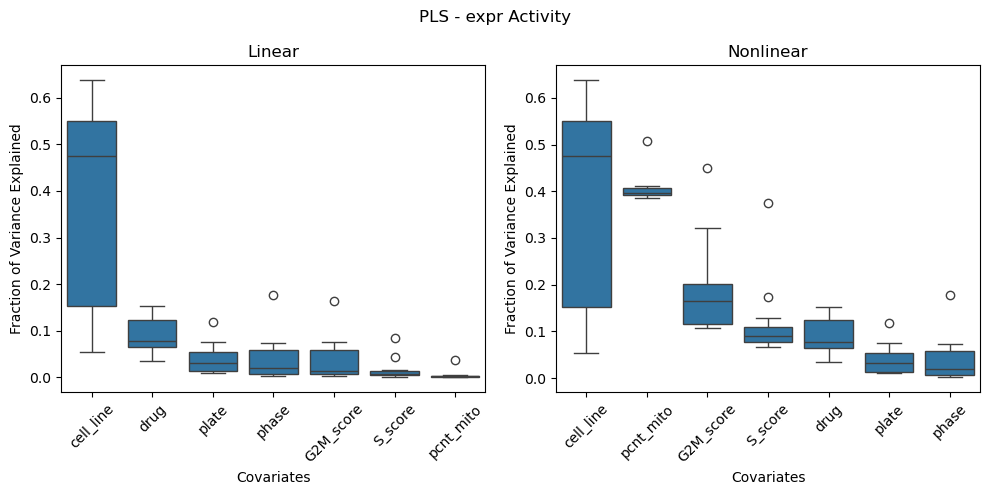

In [19]:
top_components = ls.visualize_latent_association(
    r2_df = r2_df, 
    fig_title = 'PLS - expr Activity', 
    file_name = file_prefix + '_associations.png'
)

top_components_drug = ls.get_top_components(r2_df, top_components_cov = 'drug')
top_components_cl = ls.get_top_components(r2_df, top_components_cov = 'cell_line')

In [20]:
pd.melt(
    r2_df.set_index(r2_df.columns[0]), 
    id_vars='model_type', 
    var_name='covariate'
).groupby(['model_type','covariate']).median().sort_values(by = ['model_type', 'value'])


value
model_type covariate          
linear     pcnt_mito  0.002298
           S_score    0.006748
           G2M_score  0.013574
           phase      0.019570
           plate      0.031649
           drug       0.078107
           cell_line  0.474660
nonlinear  phase      0.019570
           plate      0.031649
           drug       0.078107
           S_score    0.089715
           G2M_score  0.166074
           pcnt_mito  0.396791
           cell_line  0.474660

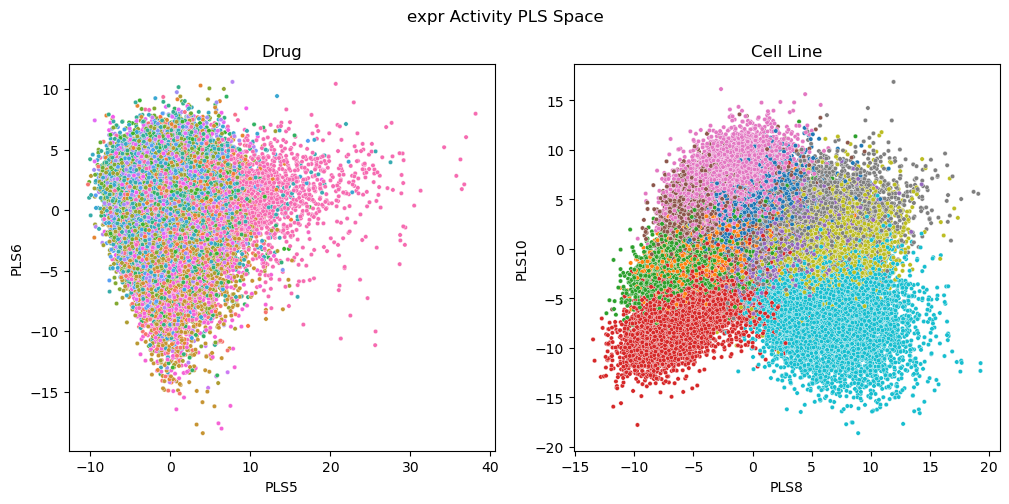

In [21]:
ls.visualize_latent_space(
    adata = adata, 
    latent_label = 'pls', 
    covariates = ['drug', 'cell_line'], 
    panel_titles = ['Drug', 'Cell Line'],
    components = {'drug': top_components_drug, 
                  'cell_line': top_components_cl}, 
    n_frac = 0.2, 
    frac_col = None, 
    fig_title = 'expr Activity PLS Space', 
    legend = False, 
    seed = 888, 
    file_name = file_prefix + '_space.png'
)

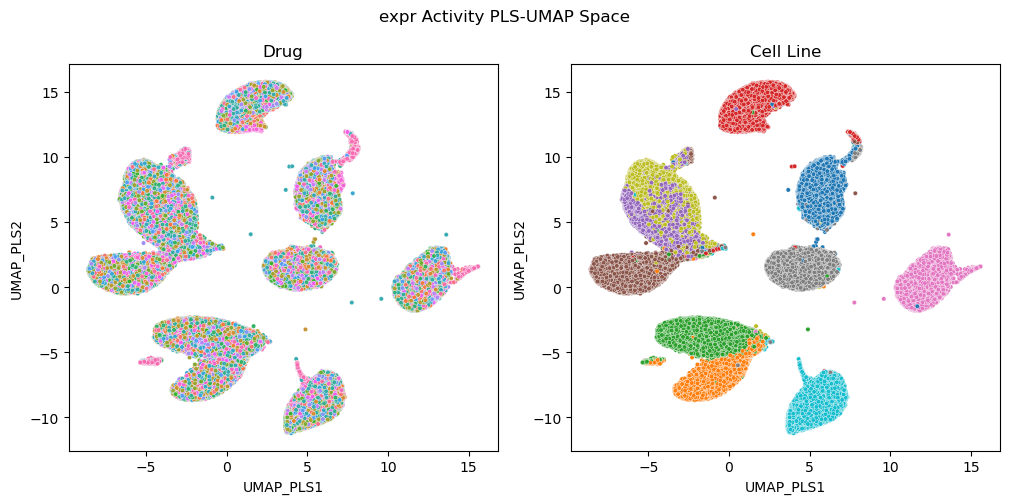

In [22]:
ls.visualize_latent_space(
    adata = adata, 
    latent_label = 'umap_pls', 
    covariates = ['drug', 'cell_line'], 
    panel_titles = ['Drug', 'Cell Line'],
    components = [1,2], 
    n_frac = 0.2, 
    frac_col = None, 
    fig_title = 'expr Activity PLS-UMAP Space', 
    legend = False, 
    seed = 888, 
    file_name = file_prefix + '_umap_space.png'
)